# Shunt Calibration: Verifying the Measurement System

**A known resistor, briefly connected, can tell you whether the entire signal chain is telling the truth.** By placing a precision resistor in parallel with one bridge arm, you create a precisely calculable resistance imbalance that the instrument *should* read as a specific simulated strain. If it does not, something in the chain — gage factor entry, excitation voltage, amplifier gain, or wiring — has an error.

*Companion notebook to Chapter 29 — Shunt Calibration: Verifying the Measurement System.*

The key insight is that shunt calibration verifies the **complete signal chain**, not just the gage. It can be performed without applying any load to the structure, at any time during a test, and from a remote location through a relay switch. That makes it the standard way to confirm a multi-channel system is reading correctly before, during, and after a test — the discipline that separates systematic experimental programs from ad hoc ones.

**This notebook demonstrates:**
1. The shunt resistor value required to simulate a target strain (e.g. 1000 με) for a given gage resistance and gage factor.
2. Simulated strain — and the raw bridge output voltage — as functions of shunt resistance, on a log scale.

Throughout we spell it **gage**, and we keep the notation identical to the chapter: gage resistance $R_g$, gage factor $GF$, shunt resistance $R_s$, and excitation $V_{ex}$.

In [1]:
# Colab: uncomment the next line to install dependencies
# !pip install numpy matplotlib

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# The book includes the figure saved below — keep this path and filename exactly.
OUT_DIR = Path("../src/media/ch29")
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

---
## 1 — Shunt resistor selection and simulated strain

When a precision resistor $R_s$ is placed in parallel with the gage arm $R_g$, the effective resistance of that arm drops to $R_g R_s / (R_g + R_s)$ (Eq. 29.1). The bridge sees this as a resistance *decrease*, which it interprets as compressive strain. Introducing the shunt into the quarter-bridge strain equation gives the **shunt calibration equation**:

$$\varepsilon_{cal} = -\frac{R_g}{GF\,(R_g + R_s)} \qquad (29.2)$$

In words: the apparent strain is always compressive (negative) for a shunt across an active arm, and it is set entirely by the gage resistance, the gage factor, and the shunt value — no mechanical load is involved.

The table below reports the simulated strain and the raw open-circuit bridge output for a set of standard precision shunt values, using a 350 Ω gage and a realistic gage factor of 2.07 (real gages are rarely exactly 2.00). The curve that follows extends this to the full practical range: very small $R_s$ simulates large — and physically unrealistic — strains, while very large $R_s$ simulates strains too small to read accurately. Inverting Eq. 29.2 tells us that a shunt of roughly 169 kΩ simulates exactly 1000 με for this gage — a common calibration target because it maps to a well-defined, easily verified bridge output.

The two small functions in the next cell implement these relations — `simulated_strain` for $\varepsilon_{cal}$ and `quarter_bridge_output_mV` for the raw bridge voltage — so the table and the plot draw from a single source of truth.

In [2]:
def shunt_effective_resistance(R_gage, R_shunt):
    """Effective arm resistance when R_shunt is in parallel with R_gage (Eq. 29.1).

    Parameters are in ohms; the return value is in ohms. Vectorized: R_shunt
    may be a NumPy array.
    """
    return R_gage * R_shunt / (R_gage + R_shunt)


def simulated_strain(R_gage, gage_factor, R_shunt):
    """Apparent strain a shunt across the active arm simulates, in microstrain.

    Implements the shunt calibration equation (Eq. 29.2),
    eps_cal = -R_g / (GF * (R_g + R_s)). The result is always negative
    (compressive) for a shunt across an active gage arm.
    """
    delta_R = shunt_effective_resistance(R_gage, R_shunt) - R_gage
    return delta_R / (gage_factor * R_gage) * 1e6


def quarter_bridge_output_mV(V_ex, R_gage, R_shunt):
    """Open-circuit quarter-bridge output for a single shunted arm, in millivolts.

    Uses the exact (nonlinear) bridge relation Vout = Vex * dR / (4*R + 2*dR),
    where dR is the resistance change the shunt produces in the active arm.
    """
    delta_R = shunt_effective_resistance(R_gage, R_shunt) - R_gage
    return V_ex * delta_R / (4 * R_gage + 2 * delta_R) * 1e3


def required_shunt(R_gage, gage_factor, target_strain_ue, N=1):
    """Shunt resistance that simulates a target strain magnitude, in ohms.

    Inverts Eq. 29.2 (with the signal-augmentation factor N for multi-arm
    bridges): R_s = R_g * 1e6 / (GF * N * eps_ue) - R_g. Pass the target
    strain magnitude in microstrain (sign omitted); N = 1 for a quarter bridge.
    """
    return R_gage * 1e6 / (gage_factor * N * target_strain_ue) - R_gage

In [3]:
# --- Measurement configuration: a 350 Ω quarter bridge, realistic gage factor ---
R_g  = 350.0    # gage resistance, Ω
GF   = 2.07     # gage factor (real gages are rarely exactly 2.00)
V_ex = 5.0      # bridge excitation, V
eps_target_ue = 1000.0   # calibration strain we want to simulate, με

# Standard precision shunt resistor values to tabulate, Ω
SHUNT_VALUES = [10e3, 22e3, 47e3, 59e3, 100e3, 150e3, 200e3]

Rs_ideal = required_shunt(R_g, GF, eps_target_ue)
print(f"For ε_sim = {eps_target_ue:.0f} με  →  Rs = {Rs_ideal/1e3:.3f} kΩ")
print()
print(f"{'Rs (kΩ)':>10}  {'ε_sim (με)':>12}  {'Vout (mV)':>12}")
print("-" * 38)
for Rs in SHUNT_VALUES:
    eps  = simulated_strain(R_g, GF, Rs)
    Vout = quarter_bridge_output_mV(V_ex, R_g, Rs)
    print(f"{Rs/1e3:>10.0f}  {eps:>12.1f}  {Vout:>12.4f}")

For ε_sim = 1000 με  →  Rs = 168.732 kΩ

   Rs (kΩ)    ε_sim (με)     Vout (mV)
--------------------------------------
        10      -16336.4      -42.9975
        22       -7565.2      -19.7294
        47       -3570.9       -9.2740
        59       -2848.9       -7.3933
       100       -1684.9       -4.3674
       150       -1124.6       -2.9133
       200        -843.9       -2.1856


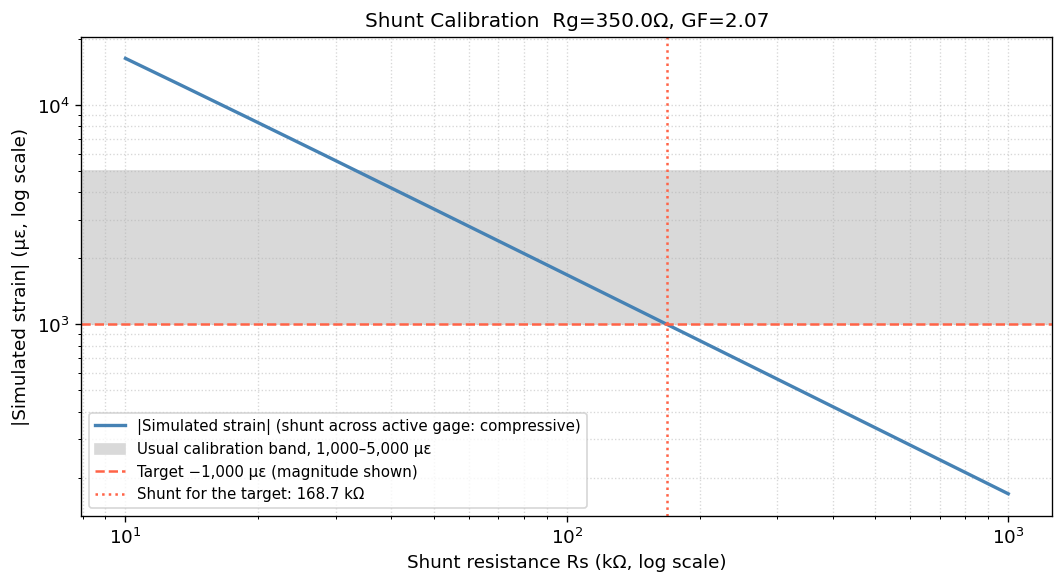

If system output ≠ calculated: GF entry, Vex, or amplifier gain has an error.


In [4]:
# Simulated strain over the shunt values actually used for calibration
# (10 kΩ … 1 MΩ). An active-gage shunt simulates COMPRESSION, so the strain is
# negative; it is plotted as a magnitude on a log axis so that the usual
# 1,000-5,000 με calibration band is readable rather than squeezed against zero.
Rs_range = np.logspace(4, 6, 300)
eps_sim = simulated_strain(R_g, GF, Rs_range)

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(Rs_range / 1000, np.abs(eps_sim), 'steelblue', lw=2,
          label='|Simulated strain| (shunt across active gage: compressive)')
ax.axhspan(1000, 5000, color='0.85', zorder=0,
           label='Usual calibration band, 1,000–5,000 με')
ax.axhline(eps_target_ue, color='tomato', lw=1.5, linestyle='--',
           label=f'Target −{eps_target_ue:,.0f} με (magnitude shown)')
ax.axvline(Rs_ideal / 1000, color='tomato', lw=1.5, linestyle=':',
           label=f'Shunt for the target: {Rs_ideal/1e3:.1f} kΩ')
ax.set_xlabel('Shunt resistance Rs (kΩ, log scale)')
ax.set_ylabel('|Simulated strain| (με, log scale)')
ax.set_title(f'Shunt Calibration  Rg={R_g}Ω, GF={GF}')
ax.legend(fontsize=9)
ax.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig29_nb1_shunt_calibration_curve.png',
            bbox_inches='tight', dpi=300)
plt.show()
print("If system output ≠ calculated: GF entry, Vex, or amplifier gain has an error.")

---
## Where to take this next

This notebook covers the workhorse case: a shunt across a single active arm of a quarter bridge. A few concrete extensions turn it into a fuller calibration tool.

1. **Add the tension (dummy-arm) shunt and compare nonlinearities.** Shunting the adjacent completion arm simulates *tension* instead of compression (Chapter 29, "Shunt Across a Completion Resistor"). Plot the compression and tension curves together and confirm they diverge only above roughly 2000 με, where the bridge nonlinearity differs between the two — reproducing the threshold the chapter cites for switching to the large-strain TN-514 relationships.

2. **Extend to half- and full-bridge configurations with the signal-augmentation factor $N$.** Use `required_shunt(..., N=...)` and Eq. 29.3 to show how the same one-arm shunt indicates a strain reduced by $N$ (e.g. $N = 2$ for a bending half bridge, $2(1+\nu)$ for a Poisson full bridge). This makes concrete why an "auto-shunt" reading disagrees with hand calculation when the instrument's assumed configuration is wrong.

3. **Build a shunt-calibration uncertainty budget.** Combine the installed-gage-resistance uncertainty ($\pm1\%$), shunt-resistor tolerance ($\pm0.01\%$), and gage-factor tolerance ($\pm1\%$) as a root-sum-square, and reproduce the chapter's result that the simulated-strain error is dominated by the gage resistance — about $\pm2.2\%$ for a 350 Ω gage at 2000 με — not by the precision shunt resistor.